In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries and KIND framework files --!

import torch
import numpy as np
from   matplotlib import pyplot as plt

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_t', 'sim',
        '--data_path', '../../data/delay/tesla_sim.csv',
        '--data_nsample', '200',
        '--data_scale_min', '-1',
        '--data_scale_max', '1',
        '--data_train_size', '0.6',
        '--data_test_size', '0.5',

        '--feature_dim', '0,1',
        '--target_dim', '0',
        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '32',
        '--learning_rate', '0.001',
        '--weight_decay', '0.0001',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/delay',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 5, "cos": 5}',
        '--fun_trans', '{"data": 8}',
    ]
)

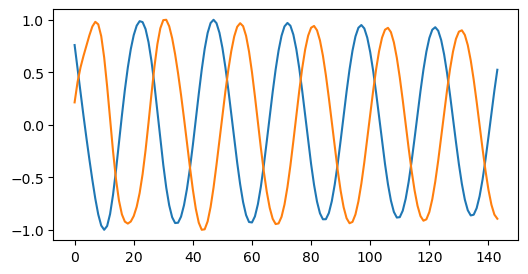

In [3]:
dataset = utils_data.dataset_factory().create_dataset(args)
dataset.plot()

In [4]:
model = kind.model(args)

In [5]:
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=0.344799, valid=0.024446, test=0.023425
	validation loss decreased (inf -> 0.024446), saving model ...
	epoch 2 losses: train=0.272609, valid=0.024991, test=0.024645
	early stopping counter: 1 out of 10
	epoch 3 losses: train=0.153746, valid=0.017074, test=0.016461
	validation loss decreased (0.024446 -> 0.017074), saving model ...
	epoch 4 losses: train=0.068821, valid=0.012017, test=0.011366
	validation loss decreased (0.017074 -> 0.012017), saving model ...
	epoch 5 losses: train=0.042359, valid=0.009575, test=0.008466
	validation loss decreased (0.012017 -> 0.009575), saving model ...
	epoch 6 losses: train=0.035260, valid=0.008306, test=0.007847
	validation loss decreased (0.009575 -> 0.008306), saving model ...
	epoch 7 losses: train=0.031465, valid=0.008153, test=0.006955
	validation loss decreased (0.008306 -> 0.008153), saving model ...
	epoch 8 losses: train=0.029905, valid=0.007694, test=0.006698
	validation loss decreased

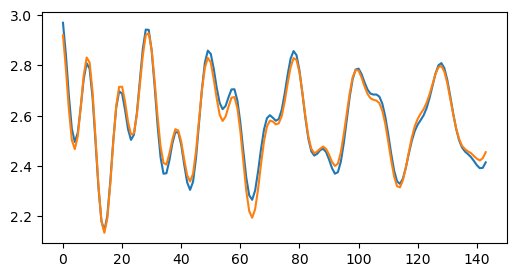

In [19]:
model.eval()
data_loader = dataset.load(flag='test')

jdata = 12

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break